In [ ]:
pip install wfdb numpy scipy matplotlib pandas scikit-learn tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 87.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.


In [ ]:
pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.2
    Uninstalling pandas-3.0.2:
      Successfully uninstalled pandas-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


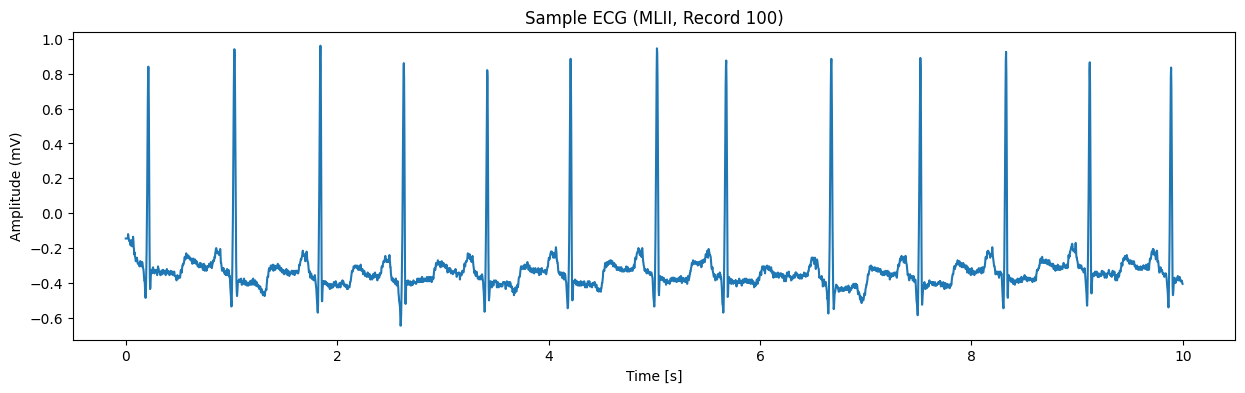

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

# Download record 100 (Normal sinus rhythm)
record = wfdb.rdrecord('100', sampto=3600, pn_dir='mitdb')
signal = record.p_signal[:,0]   # Channel MLII
fs = record.fs                  # Usually 360 Hz
time = np.arange(len(signal))/fs

plt.figure(figsize=(15, 4))
plt.plot(time, signal)
plt.title('Sample ECG (MLII, Record 100)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude (mV)')
plt.show()

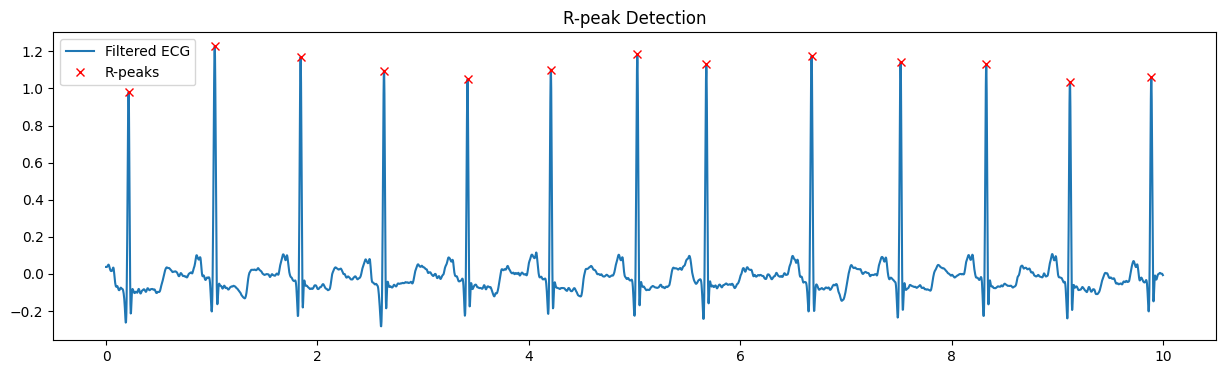

Detected 13 R-peaks in 10.0 seconds.


In [ ]:
from scipy.signal import butter, filtfilt, find_peaks

def bandpass_ecg(data, fs, low=0.5, high=40, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data)

filtered = bandpass_ecg(signal, fs)
peaks, _ = find_peaks(filtered, distance=int(0.4*fs), height=np.max(filtered)*0.5)

# R-peak marker plot
plt.figure(figsize=(15, 4))
plt.plot(time, filtered, label="Filtered ECG")
plt.plot(time[peaks], filtered[peaks], 'rx', label="R-peaks")
plt.legend()
plt.title('R-peak Detection')
plt.show()

print(f"Detected {len(peaks)} R-peaks in {len(signal)/fs:.1f} seconds.")

In [ ]:
import pandas as pd

# Load the dataset
df_train = pd.read_csv('mitbih_train.csv')

# Display the first 5 rows
display(df_train.head())

,9.779411554336547852e-01,9.264705777168273926e-01,6.813725233078002930e-01,2.450980395078659058e-01,1.544117629528045654e-01,1.911764740943908691e-01,1.519607901573181152e-01,8.578431606292724609e-02,5.882352963089942932e-02,4.901960864663124084e-02,...,0.000000000000000000e+00.79,0.000000000000000000e+00.80,0.000000000000000000e+00.81,0.000000000000000000e+00.82,0.000000000000000000e+00.83,0.000000000000000000e+00.84,0.000000000000000000e+00.85,0.000000000000000000e+00.86,0.000000000000000000e+00.87,0.000000000000000000e+00.88
0,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.927461,1.000000,0.626943,0.193437,0.094991,0.072539,0.043178,0.053541,0.093264,0.189983,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import matplotlib.pyplot as plt

# Assuming the last column is the target class and the rest are features
X_train = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]

unique_classes = y_train.unique()

plt.figure(figsize=(15, 10))

for i, class_label in enumerate(unique_classes):
    # Find the first sample for each class
    sample_index = y_train[y_train == class_label].index[0]
    sample_heartbeat = X_train.loc[sample_index]

    plt.subplot(len(unique_classes), 1, i + 1)
    plt.plot(sample_heartbeat)
    plt.title(f'Class {int(class_label)} Sample Heartbeat')
    plt.xlabel('Time Points')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [ ]:
print('Class Distribution in df_train:')
display(y_train.value_counts())

print('\nClass Distribution Percentage:')
display(y_train.value_counts(normalize=True) * 100)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
import numpy as np

# Define X and y from the loaded df_train
X = df_train.iloc[:, :-1]
y = df_train.iloc[:, -1]

# One-hot encoding for multiclass
y_cat = to_categorical(y)

# Train/val split
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y_cat, test_size=0.15, stratify=y, random_state=42)

# Model
model = Sequential([
  Conv1D(32, kernel_size=5, activation='relu', input_shape=(X.shape[1], 1)),
  MaxPooling1D(2),
  Conv1D(64, 5, activation='relu'),
  MaxPooling1D(2),
  Flatten(),
  Dense(128, activation='relu'),
  Dropout(0.5),
  Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Reshape data for Conv1D
X_train_r = X_train_split[..., np.newaxis]
X_val_r = X_val_split[..., np.newaxis]

# Training
history = model.fit(X_train_r, y_train_split, epochs=10, batch_size=128, validation_data=(X_val_r, y_val_split))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       352,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,525 (1.39 MB)

 Trainable params: 363,525 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

KeyError: (Ellipsis, None)

NameError: name 'history' is not defined

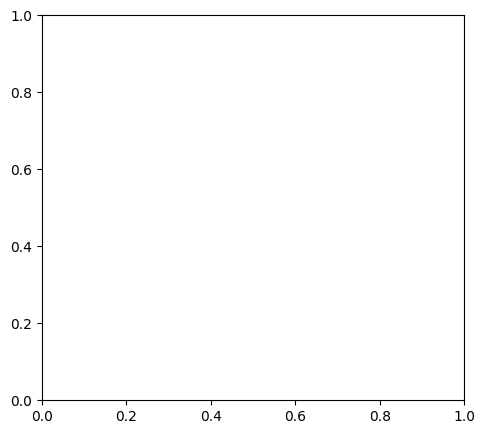

In [ ]:
# The NameError 'history' is not defined occurred because the training history object
# was not successfully captured in the kernel's state. This can happen if the
# execution of the previous cell (27aa9add) that trains the model and creates
# the `history` object was interrupted or its output truncated.
# Please ensure cell 27aa9add, which contains the model training, is run completely
# before executing this cell to ensure the `history` object is available.
# After running cell 27aa9add, you can rerun this cell.

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
import numpy as np

# Define X and y from the loaded df_train
X = df_train.iloc[:, :-1]
y = df_train.iloc[:, -1]

# One-hot encoding for multiclass
y_cat = to_categorical(y)

# Train/val split
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y_cat, test_size=0.15, stratify=y, random_state=42)

# Model
model = Sequential([
  Input(shape=(X.shape[1], 1)), # Explicit Input layer
  Conv1D(32, kernel_size=5, activation='relu'), # Removed input_shape as it's now handled by the Input layer
  MaxPooling1D(2),
  Conv1D(64, 5, activation='relu'),
  MaxPooling1D(2),
  Flatten(),
  Dense(128, activation='relu'),
  Dropout(0.5),
  Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Reshape data for Conv1D
X_train_r = X_train_split.values[..., np.newaxis] # Convert to numpy array before reshaping
X_val_r = X_val_split.values[..., np.newaxis]     # Convert to numpy array before reshaping

# Training
history = model.fit(X_train_r, y_train_split, epochs=10, batch_size=128, validation_data=(X_val_r, y_val_split))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       352,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,525 (1.39 MB)

 Trainable params: 363,525 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.9149 - loss: 0.3065 - val_accuracy: 0.9536 - val_loss: 0.1631
Epoch 2/10
249/582 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.9483 - loss: 0.1826

KeyboardInterrupt: 

In [ ]:
loss, accuracy = model.evaluate(X_val_r, y_val_split, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

In [ ]:
model.save('ecg_arrhythmia_model.h5')
print("Model saved successfully as 'ecg_arrhythmia_model.h5'")

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.utils import to_categorical

# Load the test dataset
df_test = pd.read_csv('mitbih_test.csv')

# Separate features and labels
X_test = df_test.iloc[:, :-1]
y_test = df_test.iloc[:, -1]

# One-hot encode the test labels
y_test_cat = to_categorical(y_test)

# Reshape X_test for the Conv1D layer
X_test_r = X_test.values[..., np.newaxis]

# Make predictions
predictions = model.predict(X_test_r)

# Display the first 10 raw predictions (probabilities)
print("First 10 raw predictions (probabilities):")
print(predictions[:10])

# Convert probabilities to predicted class labels
predicted_classes = np.argmax(predictions, axis=1)

print("\nFirst 10 predicted class labels:")
print(predicted_classes[:10])

print("\nFirst 10 true class labels:")
print(y_test[:10].values)

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
First 10 raw predictions (probabilities):
[[9.8975450e-01 9.1733821e-03 6.3334283e-04 2.6493453e-05 4.1227243e-04]
 [8.3704495e-01 1.5229484e-01 9.5003925e-04 5.1908183e-04 9.1912020e-03]
 [9.8906231e-01 1.0813457e-03 8.7919831e-03 2.6754770e-04 7.9690560e-04]
 [9.1772789e-01 6.3097132e-03 5.0158855e-02 7.4445568e-03 1.8358968e-02]
 [9.9949068e-01 4.3865977e-04 4.0553791e-06 1.0001155e-05 5.6493951e-05]
 [9.9897051e-01 9.0408348e-04 1.5493759e-05 7.0385693e-05 3.9444327e-05]
 [9.7412062e-01 1.2580734e-02 9.8985806e-03 1.7551486e-04 3.2245170e-03]
 [9.9485135e-01 5.1095476e-03 1.7696864e-05 2.8732914e-06 1.8669183e-05]
 [9.3006885e-01 6.5045260e-02 4.6556867e-03 7.9032434e-05 1.5117368e-04]
 [9.9936813e-01 6.1090902e-04 2.3484422e-06 3.9203669e-06 1.4648063e-05]]

First 10 predicted class labels:
[0 0 0 0 0 0 0 0 0 0]

First 10 true class labels:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Validation accuracy: 96.22%


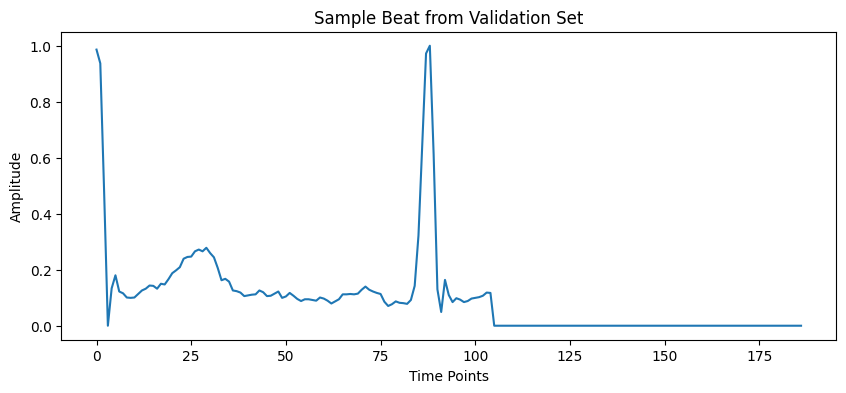

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted class: 0
Probabilities: [[9.9656063e-01 3.4222242e-03 4.5326308e-07 2.2454194e-06 1.4386666e-05]]


In [ ]:
import matplotlib.pyplot as plt

# Evaluate on validation set
loss, acc = model.evaluate(X_val_r, y_val_split, verbose=0)
print(f"Validation accuracy: {acc*100:.2f}%")

# Predict on a random beat & plot
i = np.random.randint(len(X_val_split))
beat_to_plot = X_val_split.iloc[i].values # Get the 1D beat for plotting

plt.figure(figsize=(10, 4))
plt.plot(beat_to_plot)
plt.title('Sample Beat from Validation Set')
plt.xlabel('Time Points')
plt.ylabel('Amplitude')
plt.show()

# Reshape for prediction (add batch dimension and channel dimension)
beat_for_prediction = beat_to_plot[np.newaxis,:,np.newaxis]

probs = model.predict(beat_for_prediction)
pred = np.argmax(probs)
print("Predicted class:", pred)
print("Probabilities:", probs)

In [ ]:
# Define the class labels for better interpretation
class_labels = {
    0: "Normal beat",
    1: "Supraventricular ectopic beat",
    2: "Ventricular ectopic beat",
    3: "Fusion beat",
    4: "Unknown beat"
}

def predict_heartbeat(heartbeat_data):
    # Convert the input list to a numpy array
    heartbeat_array = np.array(heartbeat_data)

    # Reshape the array to match the model's input shape (1, 187, 1)
    # Assuming the input heartbeat_data is a 1D array of 187 points
    if heartbeat_array.ndim == 1:
        heartbeat_for_prediction = heartbeat_array[np.newaxis, :, np.newaxis]
    else:
        # If it's already 2D (e.g., from CSV row), add channel dimension
        heartbeat_for_prediction = heartbeat_array[np.newaxis, :, np.newaxis]

    # Make prediction
    probabilities = model.predict(heartbeat_for_prediction, verbose=0)[0]
    predicted_class_idx = np.argmax(probabilities)
    predicted_class_label = class_labels[predicted_class_idx]

    # Format probabilities for Gradio output
    confidences = {class_labels[i]: float(probabilities[i]) for i in range(len(class_labels))}

    return predicted_class_label, confidences

In [ ]:
import numpy as np

# Class index to human-readable name
class_names = {
    0: "Normal",
    1: "Supraventricular Premature Beat",
    2: "Premature Ventricular Contraction",
    3: "Fusion of Ventricular and Normal Beat",
    4: "Unclassifiable Beat"
}

def predict_beat(beat):
    # Expecting a 1D list/array (the ECG segment)
    # Preprocess shape for model
    beat = np.array(beat).reshape(1, -1, 1)
    pred = np.argmax(model.predict(beat), axis=1)[0]
    prob = np.max(model.predict(beat))
    return f"{class_names.get(pred, 'Unknown')} (Confidence: {prob:.2f})"

In [ ]:
import gradio as gr
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd # Import pandas

# Load the dataset again to ensure df_train is defined
df_train = pd.read_csv('mitbih_train.csv')

# Redefine X and y from the loaded df_train
X = df_train.iloc[:, :-1]
y = df_train.iloc[:, -1]

# One-hot encoding for multiclass
y_cat = to_categorical(y)

# Train/val split (only need X_val_split and y_val_split for example and evaluation)
_, X_val_split, _, y_val_split = train_test_split(X, y_cat, test_size=0.15, stratify=y, random_state=42)

# Class index to human-readable name (copied from fab4dcaf for self-containment)
class_names = {
    0: "Normal",
    1: "Supraventricular Premature Beat",
    2: "Premature Ventricular Contraction",
    3: "Fusion of Ventricular and Normal Beat",
    4: "Unclassifiable Beat"
}

# predict_beat function (modified to handle 2D input from gr.Dataframe and suppress verbose output)
def predict_beat(beat):
    # Expecting a 2D numpy array from gr.Dataframe with row_count=1
    # Example: [[v1, v2, ..., v187]]
    # Preprocess shape for model
    beat = np.array(beat).reshape(1, -1, 1)
    pred = np.argmax(model.predict(beat, verbose=0), axis=1)[0]
    prob = np.max(model.predict(beat, verbose=0))
    return f"{class_names.get(pred, 'Unknown')} (Confidence: {prob:.2f})"

# Example input for testing (first sample from X_val_split, which is class 0)
# This will be a list of lists to match gr.Dataframe expected input for examples
sample_input_for_gradio_df = [X_val_split.iloc[0].tolist()]

# Define the input component separately to link the clear button
input_dataframe = gr.Dataframe(
    headers=[f'Value {i+1}' for i in range(187)],  # 187 for MIT-BIH samples
    row_count=1,
    col_count=187,
    type="numpy", # This hint is for Gradio, it will pass np.ndarray to fn
    label="ECG Beat (Paste/Enter 187 values)"
)

# Create a Gradio interface
with gr.Blocks() as iface:
    gr.Markdown("# ECG Arrhythmia AI Classifier")
    gr.Markdown("Paste an ECG beat (187 values) from the test data, or use the default example below.")

    # Input and output components
    input_dataframe.render()
    output_text = gr.Textbox(label="Prediction")

    # Buttons
    with gr.Row():
        submit_btn = gr.Button("Submit")
        clear_btn = gr.ClearButton(value="Clear", components=[input_dataframe, output_text])

    # Define interaction
    submit_btn.click(fn=predict_beat, inputs=input_dataframe, outputs=output_text, examples=[sample_input_for_gradio_df])

iface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a52c099bdaf93a3650.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


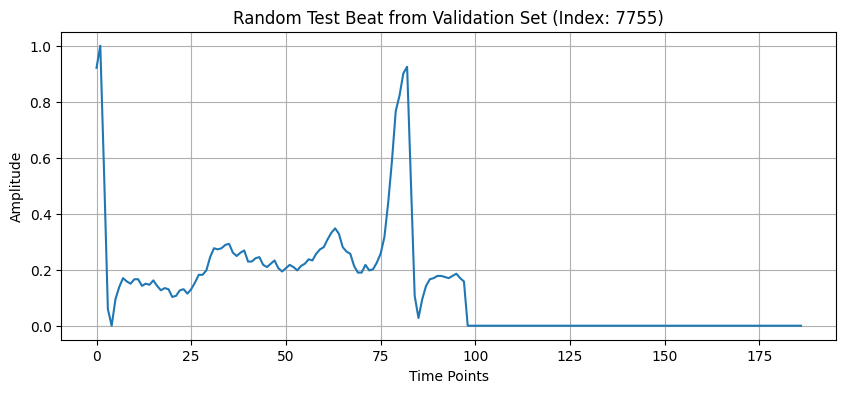

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure X_val_split is available (it should be from previous cells)
# idx = np.random.randint(len(X_val_split))

# Get a random index
idx = np.random.randint(len(X_val_split))

# Get the heartbeat data from X_val_split (which is a pandas DataFrame)
beat_to_plot = X_val_split.iloc[idx].values

plt.figure(figsize=(10, 4))
plt.plot(beat_to_plot)
plt.title(f"Random Test Beat from Validation Set (Index: {idx})")
plt.xlabel('Time Points')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

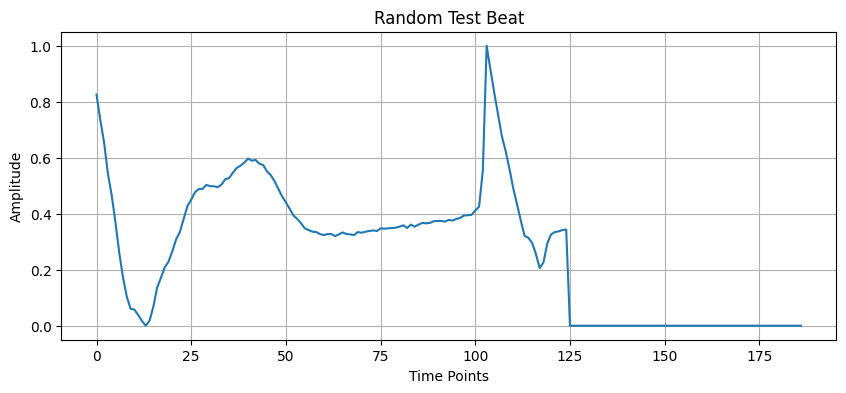

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for np.random

# Get a random index from X_val_split
idx = np.random.randint(len(X_val_split))

# Get the heartbeat data from X_val_split (which is a pandas DataFrame)
beat_to_plot = X_val_split.iloc[idx].values

plt.figure(figsize=(10, 4))
plt.plot(beat_to_plot)
plt.title("Random Test Beat")
plt.xlabel('Time Points')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()